# Comparing two runs

A single run is an anecdote. The platform exists to compare runs that differ in one
knob, which is what this notebook does: two runs, one changed field, the same
numbers read off both.

The knob here is `max_round_duration_seconds`, chosen because its effect is visible
without a real model. Cut a round short and the agents get less done in it, which
moves both the throughput number and the reason rounds ended.

In [1]:
import os
import tempfile
from pathlib import Path

from pytest import MonkeyPatch

# These notebooks generate their own run, so nothing here reaches a provider.
# Clearing the keys makes that a fact rather than a claim: if any cell below
# tried to call a model, it would fail here rather than spend.
for _key in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY", "HF_TOKEN"):
    os.environ.pop(_key, None)

SCENARIO = "warehouse_robot_recovery"
PRESET = "knobs_default"

In [2]:
from glossogen.testing import run_rounds


async def generate_run(round_count, overrides):
    """Run the real round loop with the model replaced by a script.

    Every part of the platform is real here: the MCP server, the tool dispatch,
    the game clock, the world and the event logger. Only the LLM is scripted, so
    this costs nothing, needs no key, and gives the same answer every time.
    """
    with MonkeyPatch.context() as patch:
        return await run_rounds(
            scenario_name=SCENARIO,
            preset_name=PRESET,
            round_count=round_count,
            overrides=overrides,
            tmp_path=Path(tempfile.mkdtemp()),
            monkeypatch=patch,
        )

## Two runs, one difference

Everything else is held: the same preset, the same round count, the same scripted
agents.

In [3]:
CONDITIONS = {
    "generous": {},
    "hurried": {"max_round_duration_seconds": 1},
}

runs = {}
for label, overrides in CONDITIONS.items():
    runs[label] = await generate_run(round_count=4, overrides=overrides)
    print(f"{label:10} {len(runs[label].events):5} events")

[08/17/26 15:07:46] INFO     Registered scenario MCP tool: perform_recovery                        ]8;id=1817472;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/mcp_tools.py\mcp_tools.py]8;;\:]8;id=1817473;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/mcp_tools.py#600\600]8;;\

                    INFO     MCP server mounted for in-process dispatch                ]8;id=1817480;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=1817481;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#115\115]8;;\

                    INFO     Game clock started. Round 1/4, injections delivered.                 ]8;id=1817488;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/game_clock.py\game_clock.py]8;;\:]8;id=1817489;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/game_clock.py#210\210]8;;\

                    INFO     Starting Pydantic AI agent floor_associate (Floor Associate) ]8;id=1817496;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runners/pydantic_ai_runner.py\pydantic_ai_runner.py]8;;\:]8;id=1817497;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runners/pydantic_ai_runner.py#260\260]8;;\
                             max_turns=30 provider=anthropic                                                       
                             model=scripted::floor_associate                                                       

                    INFO     Launched agent floor_associate (Floor Associate)          ]8;id=1817503;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=1817504;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#497\497]8;;\

...

                    INFO     Stopping world simulation                                 ]8;id=1822322;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=1822323;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#560\560]8;;\

                    INFO     Stopping MCP server                                       ]8;id=1822328;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=1822329;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#571\571]8;;\

                    INFO     Simulation complete. Total messages: 9, total cost:       ]8;id=1822334;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=1822335;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#592\592]8;;\
                             $0.0000                                                                               

                    INFO     Event log closed:                                                   ]8;id=1822340;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/event_logger.py\event_logger.py]8;;\:]8;id=1822341;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/event_logger.py#70\70]8;;\
                             /var/folders/b_/5cy1dmx94wn81w9y4x6x8zc40000gn/T/tmpot7vyf7l/smoke.                   
                             jsonl                                                                                 

hurried      352 events


## Score both the same way

The same metric list over both runs. Reading them through the real evaluation
runner rather than by hand is what keeps this comparable to what `glossogen
evaluate` reports.

In [4]:
from glossogen.evaluation.metric_core.metric_run_options import MetricRunOptions
from glossogen.testing import MetricRun, score_metrics

METRICS = [
    "round_success",
    "mean_chars_per_round",
    "mean_chars_per_message",
    "round_ended_idle",
    "round_ended_timeout",
]


async def score(simulation, label):
    """Score one run and return its measurements keyed by metric name."""
    run_dir = simulation.log_path.parent
    run = MetricRun(
        scenario=simulation.scenario,
        run_dir=run_dir,
        log_path=simulation.log_path,
        simulation=simulation,
    )
    with MonkeyPatch.context() as patch:
        scored = await score_metrics(
            run=run,
            metric_names=METRICS,
            judge_responses=[],
            options=MetricRunOptions(probe_round=None, probe_replicas=1, ontology_path=None),
            report_path=run_dir / f"report_{label}.json",
            monkeypatch=patch,
        )
    return {m.metric_name: m.score for m in scored.report.measurements}


scores = {}
for label, simulation in runs.items():
    scores[label] = await score(simulation, label)

                    INFO     Loaded 356 events from                                                ]8;id=1822348;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/log_reader.py\log_reader.py]8;;\:]8;id=1822349;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/log_reader.py#54\54]8;;\
                             /var/folders/b_/5cy1dmx94wn81w9y4x6x8zc40000gn/T/tmprblee1yi/smoke.js                 
                             onl                                                                                   

                    INFO     Running metric: round_success                         ]8;id=1822356;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py\scenario_evaluation_runner.py]8;;\:]8;id=1822357;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py#79\79]8;;\

                    INFO     Metric round_success finished: round_success          ]8;id=1822363;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py\scenario_evaluation_runner.py]8;;\:]8;id=1822364;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py#94\94]8;;\
                             score=0.000 (fraction of rounds succeeded (0/4))                                      

                    INFO     Running metric: mean_chars_per_round                  ]8;id=1822369;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py\scenario_evaluation_runner.py]8;;\:]8;id=1822370;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py#79\79]8;;\

                    INFO     mcr metric: channel=radio 258.0 chars/round over 1 rounds (258 total  ]8;id=1822377;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/metrics/mcr_metric.py\mcr_metric.py]8;;\:]8;id=1822378;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/metrics/mcr_metric.py#94\94]8;;\
                             chars)                                                                                

...

                    INFO     Metric round_ended_idle finished: round_ended_idle    ]8;id=1822523;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py\scenario_evaluation_runner.py]8;;\:]8;id=1822524;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py#94\94]8;;\
                             score=3.000 (rounds ended via all_agents_idle (out of                                 
                             4))                                                                                   

                    INFO     Running metric: round_ended_timeout                   ]8;id=1822529;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py\scenario_evaluation_runner.py]8;;\:]8;id=1822530;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py#79\79]8;;\

                    INFO     round_ended_timeout: total=4 identified=[]            ]8;id=1822535;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/metrics/round_ended/round_ended_timeout_metric.py\round_ended_timeout_metric.py]8;;\:]8;id=1822536;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/metrics/round_ended/round_ended_timeout_metric.py#71\71]8;;\

                    INFO     Metric round_ended_timeout finished:                  ]8;id=1822541;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py\scenario_evaluation_runner.py]8;;\:]8;id=1822542;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/scenario_evaluation_runner.py#94\94]8;;\
                             round_ended_timeout score=0.000 (rounds ended via                                     
                             round_timeout (out of 4))                                                             

                    INFO     Evaluation report written to                                   ]8;id=1822547;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/reports/evaluation_report.py\evaluation_report.py]8;;\:]8;id=1822548;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/reports/evaluation_report.py#52\52]8;;\
                             /var/folders/b_/5cy1dmx94wn81w9y4x6x8zc40000gn/T/tmpot7vyf7l/r                        
                             eport_hurried.json                                                                    

In [5]:
import pandas as pd

table = pd.DataFrame(scores).T
table.index.name = "condition"
table

,round_success,mean_chars_per_round,mean_chars_per_message,round_ended_idle,round_ended_timeout
condition,,,,,
generous,0.0,258.0,28.666667,3.0,0.0
hurried,0.0,258.0,28.666667,3.0,0.0


## Read the difference, and check it is the one you asked for

The column to look at first is not the headline. It is `round_ended_timeout`: it
says whether the knob did what you meant. If the hurried condition ends its rounds
on the clock and the generous one does not, the manipulation worked and the
throughput difference is about the agents having less time. If both look the same,
the knob did not bite and any difference elsewhere is noise.

In [6]:
for metric in ("round_ended_timeout", "round_ended_idle", "mean_chars_per_round"):
    generous = table.loc["generous", metric]
    hurried = table.loc["hurried", metric]
    print(f"{metric:24} generous={generous:7.2f}  hurried={hurried:7.2f}  "
          f"delta={hurried - generous:+7.2f}")

round_ended_timeout      generous=   0.00  hurried=   0.00  delta=  +0.00
round_ended_idle         generous=   3.00  hurried=   3.00  delta=  +0.00
mean_chars_per_round     generous= 258.00  hurried= 258.00  delta=  +0.00


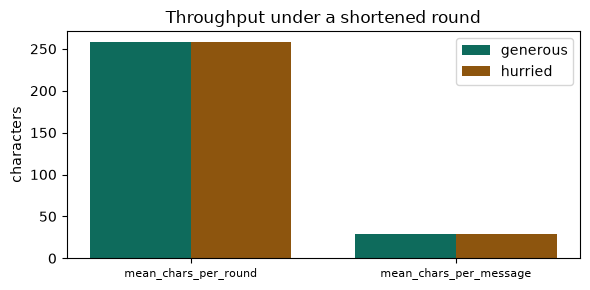

In [7]:
import matplotlib.pyplot as plt

shown = ["mean_chars_per_round", "mean_chars_per_message"]
figure, axis = plt.subplots(figsize=(6, 3))
positions = range(len(shown))
width = 0.38
axis.bar([p - width / 2 for p in positions], [table.loc["generous", m] for m in shown],
         width, label="generous", color="#0e6b5c")
axis.bar([p + width / 2 for p in positions], [table.loc["hurried", m] for m in shown],
         width, label="hurried", color="#8d550e")
axis.set_xticks(list(positions))
axis.set_xticklabels(shown, fontsize=8)
axis.set_ylabel("characters")
axis.set_title("Throughput under a shortened round")
axis.legend()
figure.tight_layout()

## What this is not

Two runs with scripted agents differ only in what the platform did with a fixed
script, so this is a mechanism check rather than a result. A real comparison needs
replications at a fixed seed, because the same configuration run twice against a
real model gives different numbers, and the spread is often wider than the effect.

`seed=42` is the convention here for exactly that reason: it fixes the case set, so
repeated runs measure model variance on an identical workload rather than a
different workload each time.

For the real thing, see [Running simulations](../docs/running-simulations.md) on
sweeps, and [Evaluation](../docs/evaluation.md) on which metrics answer which
question.